# Multi-Frame vs Bradley-Terry: A Rigorous Comparison

This notebook compares two learning approaches under the **multi-frame data generating process**:

## A) Multi-Frame Learner ("True Model")
- **DGP**: Uses `predict_response_noisy` with τ=τ'=0.25, generating 4 outcome types
- **Policy**: BALD over full 4 outcomes {left, right, indifferent, incomparable}
- **Inference**: Bayesian posterior via hit-and-run MCMC with multi-frame likelihood

## B) Bradley-Terry Baseline ("Strong BT")
- **Inference**: BT logistic model on feature differences, simplex-constrained MAP
  - Uses ONLY decisive outcomes (left/right) in likelihood
  - Ignores indifferent/incomparable in the likelihood (but remembers them for policy)
- **Policy**: BT-consistent uncertainty scoring (Fisher information style)
  - Avoids queries similar to previously rejected ones via rejection memory
  - Does NOT use multi-frame model for query selection

This is a **fair comparison**: BT gets its own optimized query selection without leakage from the multi-frame model.

In [1]:
# ============================================================================
# CELL 1: Imports, Constants, and Helper Utilities
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Set, Optional, Callable, Dict
from scipy.optimize import minimize
from scipy.special import expit as sigmoid
from scipy.stats import logistic as logistic_dist
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Constants
# ============================================================================
FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
DIM = len(FEATURE_NAMES)

# Default model parameters
TAU = 0.25           # Indifference threshold
TAU_PRIME = 0.25     # Incomparability threshold  
LAMBDA_X = 1.0       # Feature scaling

# ============================================================================
# Data Structures (from codebase)
# ============================================================================
@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: int
    lifeYearsGained: float
    obesity: int
    weeklyWorkhours: int
    yearsWaiting: int

    def to_array(self) -> np.ndarray:
        return np.array([
            self.elderlyDep, self.lifeYearsGained, self.obesity,
            self.weeklyWorkhours, self.yearsWaiting
        ], dtype=float)

@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None

# ============================================================================
# Helper Functions
# ============================================================================
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Compute cosine similarity between two vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a < 1e-10 or norm_b < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))

def entropy(probs: np.ndarray) -> float:
    """Compute entropy H[p] = -sum(p * log(p))."""
    probs = np.clip(probs, 1e-15, 1.0)
    return -np.sum(probs * np.log(probs))

def phi(query: PairwiseQuery) -> np.ndarray:
    """Feature difference vector: x_left - x_right."""
    return query.patient_left.to_array() - query.patient_right.to_array()

def generate_random_patient_normalized() -> Patient:
    """Generate a random patient with features in [0, 1]."""
    return Patient(
        elderlyDep=np.random.uniform(0, 1),
        lifeYearsGained=np.random.uniform(0, 1),
        obesity=np.random.uniform(0, 1),
        weeklyWorkhours=np.random.uniform(0, 1),
        yearsWaiting=np.random.uniform(0, 1),
    )

def generate_candidate_queries(n_candidates: int = 100) -> List[PairwiseQuery]:
    """Generate candidate queries with normalized features."""
    candidates = []
    for _ in range(n_candidates):
        left = generate_random_patient_normalized()
        right = generate_random_patient_normalized()
        candidates.append(PairwiseQuery(left, right))
    return candidates

print(f"Initialized with {DIM} features: {FEATURE_NAMES}")
print(f"Default thresholds: τ={TAU}, τ'={TAU_PRIME}")

Initialized with 5 features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
Default thresholds: τ=0.25, τ'=0.25


In [2]:
# ============================================================================
# CELL 2: Multi-Frame Model (DGP + Likelihood + Inference)
# ============================================================================
# These functions define the "true" multi-frame model used as the DGP
# and for Bayesian inference.
# ============================================================================

def compute_frame_gaps(
    query: PairwiseQuery,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    tau: float = TAU
) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active frames.
    Returns: (gaps array, set of active frame indices)
    """
    feature_diff = phi(query)
    if V is not None:
        gaps = lambda_x * (V @ feature_diff)
    else:
        gaps = lambda_x * feature_diff
    active_frames = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active_frames


def compute_aggregate_scores(
    gaps: np.ndarray,
    weights: np.ndarray,
    active_frames: Set[int]
) -> Tuple[float, float]:
    """
    Compute aggregate preference score Δ(ω) and intensity r(ω).
    """
    delta_omega = float(np.dot(gaps, weights))
    r_omega = float(sum(weights[j] * abs(gaps[j]) for j in active_frames))
    return delta_omega, r_omega


def create_noise_fn(
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0
) -> Callable:
    """
    Create noise function for latent margins.
    - Δ gets additive noise
    - r gets multiplicative noise (r̃ = r * exp(ε_r)) to stay positive
    """
    def noise_fn(delta: float, r: float) -> Tuple[float, float]:
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eps_r = np.random.logistic(0, scale_r) if scale_r > 0 else 0
        else:
            eps_delta = np.random.normal(0, scale_delta)
            eps_r = np.random.normal(0, scale_r) if scale_r > 0 else 0
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eps_r) if scale_r > 0 else r
        return delta_tilde, r_tilde
    return noise_fn


def predict_response_noisy(
    query: PairwiseQuery,
    weights: np.ndarray,
    noise_fn: Callable,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None,
) -> str:
    """
    Generate response from multi-frame model with noise.
    Returns: 'left', 'right', 'indifferent', or 'incomparable'
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, weights, active_frames)
    delta_tilde, r_tilde = noise_fn(delta, r)
    
    if r_tilde < tau:
        return 'indifferent'
    if abs(delta_tilde) < tau_prime * r_tilde:
        return 'incomparable'
    return 'left' if delta_tilde >= tau_prime * r_tilde else 'right'


def compute_response_probs_mc(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
) -> np.ndarray:
    """
    Compute P(y | q, ω) for all 4 response types using Monte Carlo.
    Returns: [p_left, p_right, p_indifferent, p_incomparable]
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    
    counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    
    for _ in range(n_mc_samples):
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eps_r = np.random.logistic(0, scale_r) if scale_r > 0 else 0
        else:
            eps_delta = np.random.normal(0, scale_delta)
            eps_r = np.random.normal(0, scale_r) if scale_r > 0 else 0
        
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eps_r) if scale_r > 0 else r
        
        if r_tilde < tau:
            counts['indifferent'] += 1
        elif abs(delta_tilde) < tau_prime * r_tilde:
            counts['incomparable'] += 1
        elif delta_tilde >= tau_prime * r_tilde:
            counts['left'] += 1
        else:
            counts['right'] += 1
    
    probs = np.array([counts['left'], counts['right'], 
                      counts['indifferent'], counts['incomparable']]) / n_mc_samples
    return probs


def compute_transcript_log_likelihood(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 100,
) -> float:
    """Compute total log-likelihood of transcript under multi-frame model."""
    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    ll = 0.0
    for query, response in transcript:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        prob = probs[response_idx[response]]
        ll += np.log(max(prob, 1e-10))
    return ll


print("Multi-frame model functions defined:")
print("  - predict_response_noisy: DGP for generating responses")
print("  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo")
print("  - compute_transcript_log_likelihood: for MCMC")

Multi-frame model functions defined:
  - predict_response_noisy: DGP for generating responses
  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo
  - compute_transcript_log_likelihood: for MCMC


In [3]:
# ============================================================================
# CELL 3: Multi-Frame MCMC Sampler
# ============================================================================

def hit_and_run_simplex_step(x: np.ndarray) -> np.ndarray:
    """
    One hit-and-run step on the simplex {w : sum(w)=1, w>=0}.
    """
    dim = len(x)
    d = np.random.randn(dim)
    d = d - d.mean()  # Project onto sum=0
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return x.copy()
    d = d / norm
    
    t_min, t_max = -np.inf, np.inf
    for j in range(dim):
        if d[j] > 1e-12:
            t_min = max(t_min, -x[j] / d[j])
        elif d[j] < -1e-12:
            t_max = min(t_max, -x[j] / d[j])
    
    if t_min >= t_max - 1e-12:
        return x.copy()
    
    t = np.random.uniform(t_min, t_max)
    new_x = x + t * d
    new_x = np.maximum(new_x, 0.0)
    new_x = new_x / new_x.sum()
    return new_x


def sample_posterior_hit_and_run(
    transcript: List[Tuple[PairwiseQuery, str]],
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_samples: int = 500,
    burn_in: int = 200,
    n_mc_samples: int = 50,
    V: np.ndarray = None,
) -> Tuple[np.ndarray, float]:
    """
    Sample from posterior P(ω | transcript) using hit-and-run + MH.
    Returns: (samples array, acceptance rate)
    """
    dim = DIM
    omega = np.ones(dim) / dim
    
    ll_current = compute_transcript_log_likelihood(
        transcript, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples
    )
    
    samples = []
    n_accepted = 0
    
    for step in range(burn_in + n_samples):
        proposal = hit_and_run_simplex_step(omega)
        ll_proposal = compute_transcript_log_likelihood(
            transcript, proposal, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        
        if np.log(np.random.rand()) < ll_proposal - ll_current:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1
        
        if step >= burn_in:
            samples.append(omega.copy())
    
    return np.array(samples), n_accepted / max(1, n_samples)


print("MCMC sampler defined: sample_posterior_hit_and_run")

MCMC sampler defined: sample_posterior_hit_and_run


In [4]:
# ============================================================================
# CELL 4: Bradley-Terry MAP Fit Under Simplex Constraints
# ============================================================================
#
# BT model: P(left | ω, q) = sigmoid(ωᵀ φ(q))
# where φ(q) = x_left - x_right and ω ∈ simplex.
#
# We fit ω by minimizing:
#   -log_likelihood + (λ/2)||ω||²
# subject to: sum(ω) = 1, ω >= 0
#
# IMPORTANT: BT only uses decisive outcomes (left/right).
# Indifferent/incomparable responses are IGNORED in the likelihood.
# ============================================================================

def fit_bt_simplex(
    transcript: List[Tuple[PairwiseQuery, str]],
    dim: int = DIM,
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
) -> np.ndarray:
    """
    Fit Bradley-Terry model with simplex constraints using SLSQP.
    
    Args:
        transcript: List of (query, response) tuples
        dim: Dimension of weight vector
        l2_reg: L2 regularization strength (λ)
        n_restarts: Number of random restarts
    
    Returns:
        omega_hat: MAP estimate on simplex
    
    Notes:
        - Uses ONLY 'left'/'right' responses (BT is binary)
        - 'indifferent'/'incomparable' responses are IGNORED
        - Numerically stable log-loss implementation
    """
    # Extract decisive outcomes only
    X, y = [], []
    for query, response in transcript:
        if response in ('left', 'right'):
            X.append(phi(query))
            y.append(1.0 if response == 'left' else 0.0)
    
    if len(X) == 0:
        return np.ones(dim) / dim  # Uniform if no decisive data
    
    X = np.array(X)
    y = np.array(y)
    
    def neg_log_posterior(omega):
        """Negative log posterior = neg log likelihood + L2 reg."""
        logits = X @ omega
        # Numerically stable log-loss
        # log(sigmoid(z)) = z - log(1 + exp(z)) for z > 0
        # log(1 - sigmoid(z)) = -log(1 + exp(z)) for z > 0
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        
        nll = -np.sum(y * log_p + (1 - y) * log_1_minus_p)
        reg = 0.5 * l2_reg * np.sum(omega ** 2)
        return nll + reg
    
    # Constraints: sum(ω) = 1
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    # Bounds: ω >= 0
    bounds = [(0, None) for _ in range(dim)]
    
    best_result = None
    for _ in range(n_restarts):
        # Random initialization on simplex
        omega0 = np.random.dirichlet(np.ones(dim))
        
        result = minimize(
            neg_log_posterior,
            omega0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        
        if best_result is None or result.fun < best_result.fun:
            best_result = result
    
    # Ensure on simplex
    omega_hat = np.maximum(best_result.x, 0)
    omega_hat = omega_hat / omega_hat.sum()
    return omega_hat


print("BT fitting function defined: fit_bt_simplex")
print("  - Uses ONLY decisive outcomes (left/right)")
print("  - Simplex constraints via SLSQP")
print("  - L2 regularization for MAP")

BT fitting function defined: fit_bt_simplex
  - Uses ONLY decisive outcomes (left/right)
  - Simplex constraints via SLSQP
  - L2 regularization for MAP


In [5]:
# ============================================================================
# CELL 5: BT Policy with Rejection Memory and Query Scoring
# ============================================================================
#
# BT Query Selection Strategy:
# 1. Uncertainty score: p*(1-p) * ||φ||² where p = sigmoid(ω̂ᵀφ)
#    This is Fisher information style - queries with p≈0.5 are most informative
# 2. Rejection penalty: Avoid queries similar to previously rejected ones
#    penalty = 1 - avoid_strength * max_cosine_sim(φ_normalized, rejected_signatures)
#
# IMPORTANT: BT scoring does NOT use τ, τ', or compute_response_probs.
# It only knows about its own logistic model.
# ============================================================================

class BTRejectionMemory:
    """
    Memory of rejected queries (indifferent/incomparable) for BT policy.
    Stores normalized φ vectors as signatures.
    """
    def __init__(self, avoid_strength: float = 0.5):
        self.signatures: List[np.ndarray] = []  # Normalized φ vectors
        self.avoid_strength = avoid_strength
    
    def add_rejection(self, query: PairwiseQuery):
        """Add a rejected query to memory."""
        phi_vec = phi(query)
        norm = np.linalg.norm(phi_vec)
        if norm > 1e-10:
            self.signatures.append(phi_vec / norm)
    
    def compute_penalty(self, query: PairwiseQuery) -> float:
        """
        Compute rejection avoidance penalty for a query.
        Returns value in [1 - avoid_strength, 1].
        """
        if len(self.signatures) == 0:
            return 1.0
        
        phi_vec = phi(query)
        norm = np.linalg.norm(phi_vec)
        if norm < 1e-10:
            return 1.0 - self.avoid_strength  # Very similar to some rejection
        
        sig = phi_vec / norm
        max_sim = max(abs(np.dot(sig, s)) for s in self.signatures)
        return 1.0 - self.avoid_strength * max(0, max_sim)


def bt_query_score(
    query: PairwiseQuery,
    omega_hat: np.ndarray,
    rejection_memory: BTRejectionMemory,
) -> float:
    """
    BT-consistent query score (Fisher information style).
    
    score = p*(1-p) * ||φ||² * rejection_penalty
    
    where:
    - p = sigmoid(ω̂ᵀφ) is BT's predicted P(left)
    - ||φ||² scales by feature difference magnitude
    - rejection_penalty avoids queries similar to past rejections
    
    This is pure BT scoring - no multi-frame model knowledge.
    """
    phi_vec = phi(query)
    logit = np.dot(omega_hat, phi_vec)
    p = sigmoid(logit)
    
    # Fisher information for logistic: p*(1-p)
    # Scale by ||φ||² (larger differences = more informative)
    uncertainty = p * (1 - p) * np.dot(phi_vec, phi_vec)
    
    # Rejection avoidance penalty
    penalty = rejection_memory.compute_penalty(query)
    
    return uncertainty * penalty


def bt_select_query(
    candidates: List[PairwiseQuery],
    omega_hat: np.ndarray,
    rejection_memory: BTRejectionMemory,
) -> PairwiseQuery:
    """Select best query according to BT scoring."""
    best_query = None
    best_score = -np.inf
    
    for query in candidates:
        score = bt_query_score(query, omega_hat, rejection_memory)
        if score > best_score:
            best_score = score
            best_query = query
    
    return best_query if best_query is not None else candidates[0]


print("BT policy functions defined:")
print("  - BTRejectionMemory: tracks rejected queries")
print("  - bt_query_score: Fisher info + rejection penalty")
print("  - bt_select_query: selects best BT query")

BT policy functions defined:
  - BTRejectionMemory: tracks rejected queries
  - bt_query_score: Fisher info + rejection penalty
  - bt_select_query: selects best BT query


In [6]:
# ============================================================================
# CELL 6: Multi-Frame BALD Query Selection
# ============================================================================
#
# BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
#
# Uses the full 4-outcome distribution from compute_response_probs_mc.
# This is the multi-frame model's query selection strategy.
# ============================================================================

def multiframe_bald_score(
    query: PairwiseQuery,
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
    max_samples: int = 50,
) -> float:
    """
    Compute BALD score for a query using full 4-outcome model.
    
    BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
    """
    n_samples = min(len(posterior_samples), max_samples)
    if n_samples == 0:
        return 0.0
    
    all_probs = []
    for omega in posterior_samples[:n_samples]:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        all_probs.append(probs)
    
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    
    return H_avg - avg_H


def multiframe_select_query(
    candidates: List[PairwiseQuery],
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
) -> PairwiseQuery:
    """Select best query according to multi-frame BALD."""
    best_query = None
    best_score = -np.inf
    
    for query in candidates:
        score = multiframe_bald_score(
            query, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V
        )
        if score > best_score:
            best_score = score
            best_query = query
    
    return best_query if best_query is not None else candidates[0]


print("Multi-frame BALD functions defined:")
print("  - multiframe_bald_score: BALD over 4 outcomes")
print("  - multiframe_select_query: selects best BALD query")

Multi-frame BALD functions defined:
  - multiframe_bald_score: BALD over 4 outcomes
  - multiframe_select_query: selects best BALD query


In [7]:
# ============================================================================
# CELL 7: Trial Runners for Both Methods
# ============================================================================

def run_bt_trial(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    avoid_strength: float = 0.5,
    l2_reg: float = 1e-2,
    seed: int = None,
) -> Dict:
    """
    Run one BT active learning trial.
    
    This is the STRONG BT baseline:
    - Query selection: BT-consistent Fisher info + rejection avoidance
    - Inference: BT MAP on simplex using only decisive outcomes
    - Policy memory: Remembers rejected queries to avoid similar ones
    
    Returns dict with:
        - cos_sims: list of cosine similarities per attempt
        - n_decisive: list of cumulative decisive count per attempt
        - responses: Counter of all responses
    """
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    transcript = []
    rejection_memory = BTRejectionMemory(avoid_strength=avoid_strength)
    omega_hat = np.ones(dim) / dim  # Start uniform
    
    cos_sims = []
    n_decisive_list = []
    responses = Counter()
    
    for t in range(n_attempts):
        # Generate candidates
        candidates = generate_candidate_queries(n_candidates)
        
        # Select query using BT scoring (no multi-frame knowledge!)
        query = bt_select_query(candidates, omega_hat, rejection_memory)
        
        # Get oracle response (from multi-frame DGP)
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((query, response))
        responses[response] += 1
        
        # Update rejection memory if non-decisive
        if response in ('indifferent', 'incomparable'):
            rejection_memory.add_rejection(query)
        
        # Re-fit BT using only decisive outcomes
        omega_hat = fit_bt_simplex(transcript, dim, l2_reg=l2_reg)
        
        # Track metrics
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        n_decisive = responses['left'] + responses['right']
        n_decisive_list.append(n_decisive)
    
    return {
        'cos_sims': cos_sims,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'final_estimate': omega_hat,
    }


def run_multiframe_trial(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    seed: int = None,
) -> Dict:
    """
    Run one multi-frame active learning trial.
    
    This is the "true model":
    - Query selection: BALD over full 4 outcomes
    - Inference: Bayesian posterior via MCMC with multi-frame likelihood
    
    Returns dict with:
        - cos_sims: list of cosine similarities per attempt
        - n_decisive: list of cumulative decisive count per attempt
        - responses: Counter of all responses
    """
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    transcript = []
    
    cos_sims = []
    n_decisive_list = []
    responses = Counter()
    
    # Initial uniform prior samples
    posterior_samples = np.random.dirichlet(np.ones(dim), size=n_posterior_samples)
    
    for t in range(n_attempts):
        # Generate candidates
        candidates = generate_candidate_queries(n_candidates)
        
        # Select query using multi-frame BALD
        query = multiframe_select_query(
            candidates, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x
        )
        
        # Get oracle response (from multi-frame DGP)
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((query, response))
        responses[response] += 1
        
        # Update posterior
        posterior_samples, _ = sample_posterior_hit_and_run(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=100,
            n_mc_samples=30,
        )
        
        # Posterior mean as point estimate
        omega_hat = posterior_samples.mean(axis=0)
        
        # Track metrics
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        n_decisive = responses['left'] + responses['right']
        n_decisive_list.append(n_decisive)
    
    return {
        'cos_sims': cos_sims,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'final_estimate': posterior_samples.mean(axis=0),
    }


print("Trial runners defined:")
print("  - run_bt_trial: Strong BT baseline with rejection memory")
print("  - run_multiframe_trial: Full Bayesian with 4-way BALD")

Trial runners defined:
  - run_bt_trial: Strong BT baseline with rejection memory
  - run_multiframe_trial: Full Bayesian with 4-way BALD


In [8]:
# ============================================================================
# CELL 8: Run Experiment
# ============================================================================

# Experiment parameters
N_TRIALS = 15          # Number of random trials
N_ATTEMPTS = 50        # Attempts per trial
N_CANDIDATES = 50     # Candidate queries per round

# Model parameters
TAU_EXP = 0.25
TAU_PRIME_EXP = 0.25
SCALE_DELTA = 0.3
SCALE_R = 0.0
NOISE_TYPE = 'logistic'

# Fixed oracle (for reproducibility)
np.random.seed(42)
ORACLE_WEIGHTS = np.random.dirichlet(np.ones(DIM))
print(f"Oracle weights: {ORACLE_WEIGHTS.round(3)}")
print(f"Settings: τ={TAU_EXP}, τ'={TAU_PRIME_EXP}, scale_δ={SCALE_DELTA}")
print(f"Running {N_TRIALS} trials × {N_ATTEMPTS} attempts each...")
print()

# Storage
bt_results = []
mf_results = []

for trial in range(N_TRIALS):
    seed = 1000 + trial
    
    # Create noise function
    noise_fn = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
    
    # Run BT trial
    np.random.seed(seed)
    noise_fn_bt = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
    bt_result = run_bt_trial(
        ORACLE_WEIGHTS, noise_fn_bt, TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
        N_ATTEMPTS, N_CANDIDATES, avoid_strength=0.5, seed=seed
    )
    bt_results.append(bt_result)
    
    # Run multi-frame trial (same seed for fair comparison)
    np.random.seed(seed)
    noise_fn_mf = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
    mf_result = run_multiframe_trial(
        ORACLE_WEIGHTS, noise_fn_mf, NOISE_TYPE, SCALE_DELTA, SCALE_R,
        TAU_EXP, TAU_PRIME_EXP, LAMBDA_X, N_ATTEMPTS, N_CANDIDATES, seed=seed
    )
    mf_results.append(mf_result)
    
    # Progress
    bt_final = bt_result['cos_sims'][-1]
    mf_final = mf_result['cos_sims'][-1]
    bt_dec = bt_result['n_decisive'][-1]
    print(f"Trial {trial+1:2d}: BT cos={bt_final:.3f} ({bt_dec} decisive), "
          f"MF cos={mf_final:.3f}")

print("\nExperiment complete!")

Oracle weights: [0.08  0.512 0.224 0.155 0.029]
Settings: τ=0.25, τ'=0.25, scale_δ=0.3
Running 15 trials × 50 attempts each...

Trial  1: BT cos=0.892 (43 decisive), MF cos=0.998
Trial  2: BT cos=0.918 (43 decisive), MF cos=1.000
Trial  3: BT cos=0.873 (35 decisive), MF cos=0.999
Trial  4: BT cos=0.953 (41 decisive), MF cos=0.999
Trial  5: BT cos=0.929 (37 decisive), MF cos=1.000
Trial  6: BT cos=0.921 (40 decisive), MF cos=0.999
Trial  7: BT cos=0.816 (41 decisive), MF cos=0.979
Trial  8: BT cos=0.943 (42 decisive), MF cos=0.999
Trial  9: BT cos=0.873 (41 decisive), MF cos=0.998
Trial 10: BT cos=0.889 (37 decisive), MF cos=0.997
Trial 11: BT cos=0.873 (40 decisive), MF cos=0.989
Trial 12: BT cos=0.873 (40 decisive), MF cos=0.986
Trial 13: BT cos=0.904 (40 decisive), MF cos=0.999
Trial 14: BT cos=0.881 (44 decisive), MF cos=0.994
Trial 15: BT cos=0.924 (40 decisive), MF cos=0.998

Experiment complete!


In [9]:
# ============================================================================
# CELL 9: Aggregate Results
# ============================================================================

# Convert to arrays for easy aggregation
bt_cos_sims = np.array([r['cos_sims'] for r in bt_results])  # (N_TRIALS, N_ATTEMPTS)
mf_cos_sims = np.array([r['cos_sims'] for r in mf_results])

bt_n_decisive = np.array([r['n_decisive'] for r in bt_results])
mf_n_decisive = np.array([r['n_decisive'] for r in mf_results])

# Compute means and standard errors
bt_mean = bt_cos_sims.mean(axis=0)
bt_stderr = bt_cos_sims.std(axis=0) / np.sqrt(N_TRIALS)

mf_mean = mf_cos_sims.mean(axis=0)
mf_stderr = mf_cos_sims.std(axis=0) / np.sqrt(N_TRIALS)

bt_dec_mean = bt_n_decisive.mean(axis=0)
bt_dec_stderr = bt_n_decisive.std(axis=0) / np.sqrt(N_TRIALS)

mf_dec_mean = mf_n_decisive.mean(axis=0)
mf_dec_stderr = mf_n_decisive.std(axis=0) / np.sqrt(N_TRIALS)

# Aggregate response counts
bt_total_responses = Counter()
mf_total_responses = Counter()
for r in bt_results:
    bt_total_responses += r['responses']
for r in mf_results:
    mf_total_responses += r['responses']

print("Aggregation complete.")
print(f"\nBT total responses across all trials: {dict(bt_total_responses)}")
print(f"MF total responses across all trials: {dict(mf_total_responses)}")

Aggregation complete.

BT total responses across all trials: {'right': 316, 'incomparable': 138, 'left': 288, 'indifferent': 8}
MF total responses across all trials: {'indifferent': 303, 'right': 196, 'left': 197, 'incomparable': 54}


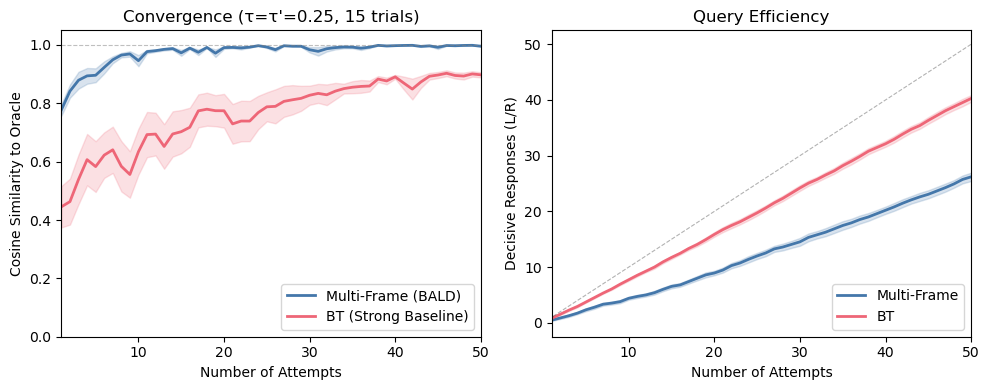


Figure saved to bt_vs_multiframe_comparison.pdf


In [ ]:
# ============================================================================
# CELL 10: Plots
# ============================================================================

# Try to use style.py if available
try:
    import sys
    sys.path.insert(0, '/Users/michellesi/Desktop/harvard/topmodel/learning-algo')
    from style import paper_style, SINGLE_COLUMN, COLOR_A, COLOR_B
    USE_STYLE = True
except:
    USE_STYLE = False
    COLOR_A = '#4477AA'  # Blue
    COLOR_B = '#EE6677'  # Red

attempts = np.arange(1, N_ATTEMPTS + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left plot: Cosine similarity convergence
ax1 = axes[0]
ax1.plot(attempts, mf_mean, '-', color=COLOR_A, label='Multi-Frame (BALD)', linewidth=2)
ax1.fill_between(attempts, mf_mean - mf_stderr, mf_mean + mf_stderr, 
                  color=COLOR_A, alpha=0.2)
ax1.plot(attempts, bt_mean, '-', color=COLOR_B, label='BT (Strong Baseline)', linewidth=2)
ax1.fill_between(attempts, bt_mean - bt_stderr, bt_mean + bt_stderr,
                  color=COLOR_B, alpha=0.2)
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.set_xlabel('Number of Queries')
ax1.set_ylabel('Cosine Similarity to Oracle')
ax1.set_title(f'Convergence (τ=τ\'={TAU_EXP}, {N_TRIALS} trials)')
ax1.legend(loc='lower right')
ax1.set_ylim([0, 1.05])
ax1.set_xlim([1, N_ATTEMPTS])

# Right plot: Decisive queries obtained
ax2 = axes[1]
ax2.plot(attempts, mf_dec_mean, '-', color=COLOR_A, label='Multi-Frame', linewidth=2)
ax2.fill_between(attempts, mf_dec_mean - mf_dec_stderr, mf_dec_mean + mf_dec_stderr,
                  color=COLOR_A, alpha=0.2)
ax2.plot(attempts, bt_dec_mean, '-', color=COLOR_B, label='BT', linewidth=2)
ax2.fill_between(attempts, bt_dec_mean - bt_dec_stderr, bt_dec_mean + bt_dec_stderr,
                  color=COLOR_B, alpha=0.2)
ax2.plot([0, N_ATTEMPTS], [0, N_ATTEMPTS], 'k--', alpha=0.3, linewidth=0.8)
ax2.set_xlabel('Number of Queries')
ax2.set_ylabel('Decisive Responses (L/R)')
ax2.set_title('Query Efficiency')
ax2.legend(loc='lower right')
ax2.set_xlim([1, N_ATTEMPTS])

plt.tight_layout()
plt.savefig('bt_vs_multiframe_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

print("\nFigure saved to bt_vs_multiframe_comparison.pdf")

In [11]:
# ============================================================================
# CELL 11: Summary Table
# ============================================================================

print("=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print(f"\nSettings:")
print(f"  Oracle weights: {ORACLE_WEIGHTS.round(3)}")
print(f"  τ = τ' = {TAU_EXP}")
print(f"  Noise: {NOISE_TYPE}, scale_δ = {SCALE_DELTA}, scale_r = {SCALE_R}")
print(f"  Trials: {N_TRIALS}, Attempts per trial: {N_ATTEMPTS}")

print(f"\n{'Metric':<30} {'Multi-Frame':>15} {'BT (Strong)':>15}")
print("-" * 60)

# Final cosine similarity
print(f"{'Final cos_sim (mean ± SE)':<30} {mf_mean[-1]:.3f} ± {mf_stderr[-1]:.3f}     {bt_mean[-1]:.3f} ± {bt_stderr[-1]:.3f}")

# Cosine at midpoint
mid = N_ATTEMPTS // 2 - 1
print(f"{'Cos_sim at t={N_ATTEMPTS//2} (mean ± SE)':<30} {mf_mean[mid]:.3f} ± {mf_stderr[mid]:.3f}     {bt_mean[mid]:.3f} ± {bt_stderr[mid]:.3f}")

# Decisive rate
bt_dec_rate = bt_dec_mean[-1] / N_ATTEMPTS
mf_dec_rate = mf_dec_mean[-1] / N_ATTEMPTS
print(f"{'Decisive rate (final)':<30} {mf_dec_rate:.1%}            {bt_dec_rate:.1%}")

# Response breakdown
print(f"\nResponse breakdown (total across all trials):")
print(f"  Multi-Frame: {dict(mf_total_responses)}")
print(f"  BT:          {dict(bt_total_responses)}")

# Statistical test
from scipy.stats import ttest_ind
final_mf = [r['cos_sims'][-1] for r in mf_results]
final_bt = [r['cos_sims'][-1] for r in bt_results]
t_stat, p_value = ttest_ind(final_mf, final_bt)
print(f"\nTwo-sample t-test (final cos_sim): t={t_stat:.2f}, p={p_value:.4f}")
if p_value < 0.05:
    winner = "Multi-Frame" if np.mean(final_mf) > np.mean(final_bt) else "BT"
    print(f"  → {winner} significantly better at α=0.05")
else:
    print(f"  → No significant difference at α=0.05")

print("\n" + "=" * 70)

EXPERIMENT SUMMARY

Settings:
  Oracle weights: [0.08  0.512 0.224 0.155 0.029]
  τ = τ' = 0.25
  Noise: logistic, scale_δ = 0.3, scale_r = 0.0
  Trials: 15, Attempts per trial: 50

Metric                             Multi-Frame     BT (Strong)
------------------------------------------------------------
Final cos_sim (mean ± SE)      0.996 ± 0.002     0.898 ± 0.009
Cos_sim at t={N_ATTEMPTS//2} (mean ± SE) 0.993 ± 0.004     0.788 ± 0.050
Decisive rate (final)          52.4%            80.5%

Response breakdown (total across all trials):
  Multi-Frame: {'indifferent': 303, 'right': 196, 'left': 197, 'incomparable': 54}
  BT:          {'right': 316, 'incomparable': 138, 'left': 288, 'indifferent': 8}

Two-sample t-test (final cos_sim): t=10.68, p=0.0000
  → Multi-Frame significantly better at α=0.05



# Protocol 2: Fixed Decisive Budget

**Question**: If we give both methods the same amount of *usable* information, how do they compare?

- **BT**: Run until it collects K=50 decisive labels (left/right). Track total attempts needed.
- **Multi-Frame**: Run for exactly K=50 queries. It uses ALL responses for inference.

This compares:
1. Cosine similarity vs. decisive labels (what BT actually uses)
2. How many extra attempts BT needs to get K decisive labels
3. Multi-frame's performance with the same query budget as BT's decisive count

In [12]:
# ============================================================================
# CELL 12: Protocol 2 - Trial Runners for Fixed Decisive Budget
# ============================================================================

def run_bt_until_k_decisive(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    k_decisive: int,
    n_candidates: int = 100,
    avoid_strength: float = 0.5,
    l2_reg: float = 1e-2,
    max_attempts: int = 500,  # Safety limit
    seed: int = None,
) -> Dict:
    """
    Run BT until it collects exactly k_decisive left/right responses.
    
    Returns dict with:
        - cos_sims_by_decisive: cosine sim after each decisive label (length = k_decisive)
        - total_attempts: how many queries were needed
        - responses: Counter of all responses
    """
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    transcript = []
    rejection_memory = BTRejectionMemory(avoid_strength=avoid_strength)
    omega_hat = np.ones(dim) / dim
    
    cos_sims_by_decisive = []  # Track cos_sim after each decisive response
    responses = Counter()
    n_decisive = 0
    attempt = 0
    
    while n_decisive < k_decisive and attempt < max_attempts:
        candidates = generate_candidate_queries(n_candidates)
        query = bt_select_query(candidates, omega_hat, rejection_memory)
        
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((query, response))
        responses[response] += 1
        attempt += 1
        
        if response in ('indifferent', 'incomparable'):
            rejection_memory.add_rejection(query)
        else:
            # Decisive response - update estimate and record
            n_decisive += 1
            omega_hat = fit_bt_simplex(transcript, dim, l2_reg=l2_reg)
            cos_sims_by_decisive.append(cosine_similarity(omega_hat, oracle_weights))
    
    return {
        'cos_sims_by_decisive': cos_sims_by_decisive,
        'total_attempts': attempt,
        'n_decisive': n_decisive,
        'responses': responses,
        'final_estimate': omega_hat,
    }


def run_multiframe_k_queries(
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    k_queries: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    seed: int = None,
) -> Dict:
    """
    Run multi-frame for exactly k_queries.
    Track cosine sim after each query (to compare with BT's per-decisive).
    
    Returns dict with:
        - cos_sims: cosine sim after each query (length = k_queries)
        - n_decisive: how many were decisive
        - responses: Counter of all responses
    """
    if seed is not None:
        np.random.seed(seed)
    
    dim = len(oracle_weights)
    transcript = []
    
    cos_sims = []
    responses = Counter()
    
    posterior_samples = np.random.dirichlet(np.ones(dim), size=n_posterior_samples)
    
    for t in range(k_queries):
        candidates = generate_candidate_queries(n_candidates)
        query = multiframe_select_query(
            candidates, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x
        )
        
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime
        )
        transcript.append((query, response))
        responses[response] += 1
        
        posterior_samples, _ = sample_posterior_hit_and_run(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=100,
            n_mc_samples=30,
        )
        
        omega_hat = posterior_samples.mean(axis=0)
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
    
    return {
        'cos_sims': cos_sims,
        'n_decisive': responses['left'] + responses['right'],
        'responses': responses,
        'final_estimate': posterior_samples.mean(axis=0),
    }


print("Protocol 2 trial runners defined:")
print("  - run_bt_until_k_decisive: run BT until K decisive labels")
print("  - run_multiframe_k_queries: run multi-frame for K queries")

Protocol 2 trial runners defined:
  - run_bt_until_k_decisive: run BT until K decisive labels
  - run_multiframe_k_queries: run multi-frame for K queries


In [13]:
# ============================================================================
# CELL 13: Run Protocol 2 Experiment
# ============================================================================

K_DECISIVE = 50  # Target number of decisive labels for BT

print(f"Protocol 2: BT runs until {K_DECISIVE} decisive labels")
print(f"            Multi-frame runs for {K_DECISIVE} queries")
print(f"Running {N_TRIALS} trials...")
print()

# Storage
bt_p2_results = []
mf_p2_results = []

for trial in range(N_TRIALS):
    seed = 2000 + trial  # Different seed range from Protocol 1
    
    # Run BT until K decisive
    np.random.seed(seed)
    noise_fn_bt = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
    bt_result = run_bt_until_k_decisive(
        ORACLE_WEIGHTS, noise_fn_bt, TAU_EXP, TAU_PRIME_EXP, LAMBDA_X,
        K_DECISIVE, N_CANDIDATES, avoid_strength=0.5, seed=seed
    )
    bt_p2_results.append(bt_result)
    
    # Run multi-frame for K queries
    np.random.seed(seed)
    noise_fn_mf = create_noise_fn(NOISE_TYPE, SCALE_DELTA, SCALE_R)
    mf_result = run_multiframe_k_queries(
        ORACLE_WEIGHTS, noise_fn_mf, NOISE_TYPE, SCALE_DELTA, SCALE_R,
        TAU_EXP, TAU_PRIME_EXP, LAMBDA_X, K_DECISIVE, N_CANDIDATES, seed=seed
    )
    mf_p2_results.append(mf_result)
    
    # Progress
    bt_attempts = bt_result['total_attempts']
    bt_final = bt_result['cos_sims_by_decisive'][-1] if bt_result['cos_sims_by_decisive'] else 0
    mf_final = mf_result['cos_sims'][-1]
    mf_dec = mf_result['n_decisive']
    print(f"Trial {trial+1:2d}: BT needed {bt_attempts} attempts (cos={bt_final:.3f}), "
          f"MF got {mf_dec} decisive in {K_DECISIVE} queries (cos={mf_final:.3f})")

print("\nProtocol 2 experiment complete!")

Protocol 2: BT runs until 50 decisive labels
            Multi-frame runs for 50 queries
Running 15 trials...

Trial  1: BT needed 56 attempts (cos=0.761), MF got 23 decisive in 50 queries (cos=0.995)
Trial  2: BT needed 55 attempts (cos=0.869), MF got 31 decisive in 50 queries (cos=1.000)
Trial  3: BT needed 62 attempts (cos=0.899), MF got 28 decisive in 50 queries (cos=0.996)
Trial  4: BT needed 57 attempts (cos=0.769), MF got 29 decisive in 50 queries (cos=0.995)
Trial  5: BT needed 54 attempts (cos=0.873), MF got 28 decisive in 50 queries (cos=0.998)
Trial  6: BT needed 54 attempts (cos=0.873), MF got 25 decisive in 50 queries (cos=0.757)
Trial  7: BT needed 61 attempts (cos=0.873), MF got 28 decisive in 50 queries (cos=0.998)
Trial  8: BT needed 59 attempts (cos=0.921), MF got 27 decisive in 50 queries (cos=0.994)
Trial  9: BT needed 60 attempts (cos=0.949), MF got 23 decisive in 50 queries (cos=0.929)
Trial 10: BT needed 68 attempts (cos=0.873), MF got 31 decisive in 50 queries (

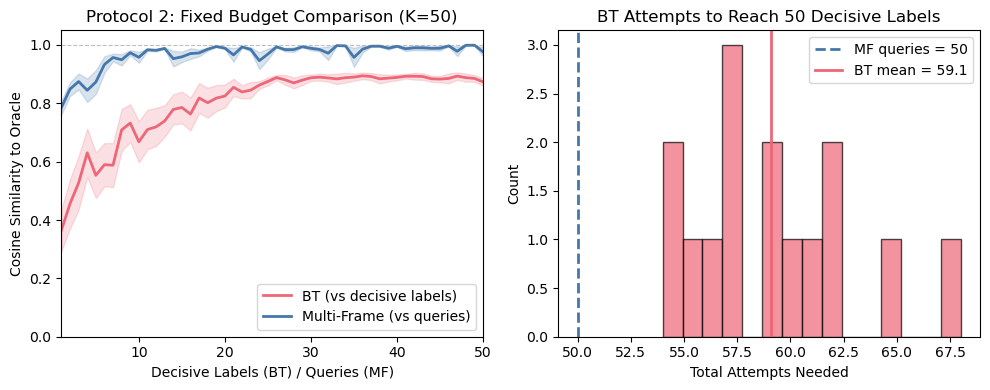

Figure saved to protocol2_fixed_budget.pdf


In [14]:
# ============================================================================
# CELL 14: Protocol 2 - Aggregate and Plot
# ============================================================================

# Aggregate BT results (indexed by decisive label count)
bt_p2_cos_sims = np.array([r['cos_sims_by_decisive'] for r in bt_p2_results])  # (N_TRIALS, K_DECISIVE)
bt_p2_attempts = np.array([r['total_attempts'] for r in bt_p2_results])

# Aggregate MF results (indexed by query count)
mf_p2_cos_sims = np.array([r['cos_sims'] for r in mf_p2_results])  # (N_TRIALS, K_DECISIVE)
mf_p2_n_decisive = np.array([r['n_decisive'] for r in mf_p2_results])

# Compute means and stderr
bt_p2_mean = bt_p2_cos_sims.mean(axis=0)
bt_p2_stderr = bt_p2_cos_sims.std(axis=0) / np.sqrt(N_TRIALS)

mf_p2_mean = mf_p2_cos_sims.mean(axis=0)
mf_p2_stderr = mf_p2_cos_sims.std(axis=0) / np.sqrt(N_TRIALS)

decisive_labels = np.arange(1, K_DECISIVE + 1)

# ============================================================================
# Plot 1: Cosine similarity vs decisive labels / queries
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax1 = axes[0]
ax1.plot(decisive_labels, bt_p2_mean, '-', color=COLOR_B, 
         label=f'BT (vs decisive labels)', linewidth=2)
ax1.fill_between(decisive_labels, bt_p2_mean - bt_p2_stderr, bt_p2_mean + bt_p2_stderr,
                  color=COLOR_B, alpha=0.2)
ax1.plot(decisive_labels, mf_p2_mean, '-', color=COLOR_A,
         label=f'Multi-Frame (vs queries)', linewidth=2)
ax1.fill_between(decisive_labels, mf_p2_mean - mf_p2_stderr, mf_p2_mean + mf_p2_stderr,
                  color=COLOR_A, alpha=0.2)
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.set_xlabel('Decisive Labels (BT) / Queries (MF)')
ax1.set_ylabel('Cosine Similarity to Oracle')
ax1.set_title(f'Protocol 2: Fixed Budget Comparison (K={K_DECISIVE})')
ax1.legend(loc='lower right')
ax1.set_ylim([0, 1.05])
ax1.set_xlim([1, K_DECISIVE])

# Plot 2: Distribution of attempts needed by BT
ax2 = axes[1]
ax2.hist(bt_p2_attempts, bins=15, color=COLOR_B, alpha=0.7, edgecolor='black')
ax2.axvline(x=K_DECISIVE, color=COLOR_A, linestyle='--', linewidth=2, 
            label=f'MF queries = {K_DECISIVE}')
ax2.axvline(x=bt_p2_attempts.mean(), color=COLOR_B, linestyle='-', linewidth=2,
            label=f'BT mean = {bt_p2_attempts.mean():.1f}')
ax2.set_xlabel('Total Attempts Needed')
ax2.set_ylabel('Count')
ax2.set_title(f'BT Attempts to Reach {K_DECISIVE} Decisive Labels')
ax2.legend()

plt.tight_layout()
plt.savefig('protocol2_fixed_budget.pdf', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved to protocol2_fixed_budget.pdf")

In [ ]:
# ============================================================================
# CELL 15: Protocol 2 - Summary Table
# ============================================================================

print("=" * 70)
print("PROTOCOL 2 SUMMARY: Fixed Decisive Budget")
print("=" * 70)

print(f"\nSetup:")
print(f"  BT: Run until {K_DECISIVE} decisive labels collected")
print(f"  Multi-Frame: Run for exactly {K_DECISIVE} queries")

print(f"\n{'Metric':<40} {'Multi-Frame':>12} {'BT':>12}")
print("-" * 65)

# Final cosine similarity
mf_final_mean = mf_p2_cos_sims[:, -1].mean()
mf_final_se = mf_p2_cos_sims[:, -1].std() / np.sqrt(N_TRIALS)
bt_final_mean = bt_p2_cos_sims[:, -1].mean()
bt_final_se = bt_p2_cos_sims[:, -1].std() / np.sqrt(N_TRIALS)
print(f"{'Final cos_sim (mean ± SE)':<40} {mf_final_mean:.3f}±{mf_final_se:.3f}    {bt_final_mean:.3f}±{bt_final_se:.3f}")

# Queries/attempts used
print(f"{'Queries used (mean ± SE)':<40} {K_DECISIVE:.1f}±0.0        {bt_p2_attempts.mean():.1f}±{bt_p2_attempts.std()/np.sqrt(N_TRIALS):.1f}")

# Overhead ratio
overhead = bt_p2_attempts.mean() / K_DECISIVE
print(f"{'Attempt overhead ratio (BT/K)':<40} {'1.00':>12} {overhead:.2f}")

# Decisive rate for MF
mf_dec_rate = mf_p2_n_decisive.mean() / K_DECISIVE
print(f"{'MF decisive rate':<40} {mf_dec_rate:.1%}")

print(f"\n{'At midpoint (K/2 = '}{K_DECISIVE//2}{'):':<28} {'Multi-Frame':>12} {'BT':>12}")
print("-" * 65)
mid = K_DECISIVE // 2 - 1
mf_mid = mf_p2_cos_sims[:, mid].mean()
bt_mid = bt_p2_cos_sims[:, mid].mean()
print(f"{'Cos_sim':<40} {mf_mid:.3f}         {bt_mid:.3f}")

# Statistical comparison at final point
print(f"\nStatistical Tests:")
final_mf = mf_p2_cos_sims[:, -1]
final_bt = bt_p2_cos_sims[:, -1]

# Test 1: Final cosine similarity
t_stat, p_value = ttest_ind(final_mf, final_bt)
print(f"  Final cos_sim t-test: t={t_stat:.2f}, p={p_value:.4f}")
if p_value < 0.05:
    winner = "Multi-Frame" if final_mf.mean() > final_bt.mean() else "BT"
    print(f"    → {winner} significantly better")

# Test 2: Is BT overhead significant?
# Compare BT attempts to K_DECISIVE
from scipy.stats import ttest_1samp
t_stat2, p_value2 = ttest_1samp(bt_p2_attempts, K_DECISIVE)
print(f"  BT attempts vs K={K_DECISIVE}: t={t_stat2:.2f}, p={p_value2:.4f}")
if p_value2 < 0.05 and bt_p2_attempts.mean() > K_DECISIVE:
    print(f"    → BT needs significantly more attempts than K")

print(f"\nInterpretation:")
print(f"  - BT needed {overhead:.1%} as many attempts to get {K_DECISIVE} usable labels")
print(f"  - Multi-Frame used ALL {K_DECISIVE} responses for inference")
if final_mf.mean() > final_bt.mean():
    gap = final_mf.mean() - final_bt.mean()
    print(f"  - Multi-Frame achieved {gap:.3f} higher cos_sim with same 'usable' data budget")
else:
    gap = final_bt.mean() - final_mf.mean()
    print(f"  - BT achieved {gap:.3f} higher cos_sim despite query overhead")

print("\n" + "=" * 70)